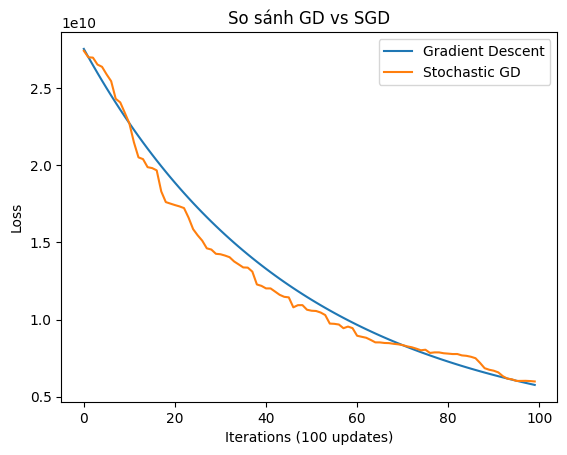

Final GD loss: 5766624713.743129
Final SGD loss: 5990468176.626868


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ===== 1. LOAD DATA =====
df = pd.read_csv("../datasets/housing.csv")

# ===== 2. XỬ LÝ DATA =====
# Encode categorical
df = pd.get_dummies(df, columns=['ocean_proximity'])

# Xóa missing
df = df.dropna()

# Tách X, y
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values.reshape(-1,1)

# Chuẩn hóa
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias
X = np.c_[np.ones((X.shape[0], 1)), X]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===== 3. KHỞI TẠO =====
theta_gd = np.zeros((X.shape[1], 1))
theta_sgd = np.zeros((X.shape[1], 1))

lr = 0.01
m = len(X_train)

# Loss function
def compute_loss(X, y, theta):
    return (1/(2*len(X))) * np.sum((X.dot(theta) - y)**2)

loss_gd = []
loss_sgd = []

# ===== 4. GRADIENT DESCENT =====
for _ in range(100):
    gradients = (1/m) * X_train.T.dot(X_train.dot(theta_gd) - y_train)
    theta_gd = theta_gd - lr * gradients
    loss_gd.append(compute_loss(X_train, y_train, theta_gd))

# ===== 5. STOCHASTIC GD =====
for _ in range(100):
    i = np.random.randint(m)
    xi = X_train[i:i+1]
    yi = y_train[i:i+1]

    gradients = xi.T.dot(xi.dot(theta_sgd) - yi)
    theta_sgd = theta_sgd - lr * gradients

    loss_sgd.append(compute_loss(X_train, y_train, theta_sgd))

# ===== 6. VẼ BIỂU ĐỒ =====
plt.figure()
plt.plot(loss_gd, label="Gradient Descent")
plt.plot(loss_sgd, label="Stochastic GD")
plt.xlabel("Iterations (100 updates)")
plt.ylabel("Loss")
plt.title("So sánh GD vs SGD")
plt.legend()
plt.show()

# ===== 7. ĐÁNH GIÁ =====
print("Final GD loss:", loss_gd[-1])
print("Final SGD loss:", loss_sgd[-1])